# ST-GCN + LSTM 실시간 Phase 기반 Count 프로토타입

`exercise_stgcn_v4.ipynb`의 **영상/라벨 경로, pose 형식, 정규화, phase 정의, ST-GCN backbone**을 최대한 유지하고, 아래만 실시간 causal 방식에 맞게 변경한 버전입니다.

- 입력: 최근 `96`프레임 pose window
- 정답: window의 **마지막 frame phase**
- 구조: `ST-GCN backbone → joint pooling → LSTM → current phase head`
- count: 예측 phase sequence smoothing 후 `up phase 종료` 기준 count
- workspace: `/content/drive/MyDrive/data/유영진/STGCN_LSTM`

주의: temporal speed/resample, synthetic rep stitching처럼 시간 흐름을 바꾸는 augmentation은 기본 비활성화했습니다. 공간 augmentation만 사용합니다.

## 1. 패키지 설치

첫 실행 후 `Runtime → Restart session`을 권장합니다.

## 2. Import / Drive mount / Seed

In [1]:


import os, json, math, random, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    mean_absolute_error
)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch:', torch.__version__, '| numpy:', np.__version__)

device: cuda | torch: 2.11.0+cu128 | numpy: 2.4.4


## 3. 경로 + 상수

영상/라벨 경로는 기존 코드와 동일하게 두고, 결과 저장 workspace만 새로 분리합니다.

In [2]:
ROOT      = Path('../data/측면/data')
VIDEO_DIR = ROOT
LABEL_DIR = ROOT / 'labels'

# workspace / pose cache. 있으면 읽어서 재사용합니다.
TEAM_WORK_DIR = ROOT / 'workdir'
TEAM_POSE_DIR = TEAM_WORK_DIR / 'poses'
TEAM_META_CSV = TEAM_WORK_DIR / 'meta_v4.csv'

# 새 workspace: 결과 저장은 전부 여기로 합니다.
WORK_DIR  = ROOT / 'STGCN_LSTM'
POSE_DIR  = WORK_DIR / 'poses'
CKPT_DIR  = WORK_DIR / 'checkpoints'
PLOT_DIR  = WORK_DIR / 'plots'
CSV_DIR   = WORK_DIR / 'csv'
TMP_DIR   = WORK_DIR / 'tmp'

for d in [WORK_DIR, POSE_DIR, CKPT_DIR, PLOT_DIR, CSV_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_LIST  = ['squat', 'benchpress', 'deadlift']
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_LIST)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
NUM_CLASSES = len(CLASS_LIST)

PHASE_READY = 0
PHASE_DOWN  = 1
PHASE_UP    = 2
NUM_PHASES  = 3
PHASE_NAMES = ['ready', 'down', 'up']

CLIP_LEN = 32
TRAIN_STRIDE = 2
VAL_STRIDE = 1
INFERENCE_STRIDE = 1

print('ROOT     :', ROOT)
print('WORK_DIR :', WORK_DIR)
print('TEAM_POSE_DIR exists:', TEAM_POSE_DIR.exists())
print('TEAM_META_CSV exists:', TEAM_META_CSV.exists())

ROOT     : ..\data\측면\data
WORK_DIR : ..\data\측면\data\STGCN_LSTM
TEAM_POSE_DIR exists: True
TEAM_META_CSV exists: True


## 4. 라벨 CSV 읽기 / phase label 파싱

In [3]:
csv_list = sorted(LABEL_DIR.glob('*.csv'))
assert len(csv_list) > 0, f'라벨 CSV 없음: {LABEL_DIR}'

# 여러 CSV가 있으면 아래 LABEL_CSV를 명시적으로 바꾸는 것을 추천합니다.
LABEL_CSV = csv_list[0]
print('라벨 파일:', LABEL_CSV)

raw_df = pd.read_csv(LABEL_CSV)
raw_df.columns = [str(c).strip() for c in raw_df.columns]
raw_df = raw_df.loc[:, ~raw_df.columns.str.startswith('Unnamed')]
print('raw label shape:', raw_df.shape)
print('columns:', list(raw_df.columns)[:20])

L_cols = sorted([c for c in raw_df.columns if c.startswith('L')],
                key=lambda x: int(x[1:]) if x[1:].isdigit() else 9999)
print(f'L 컬럼: {len(L_cols)}개')

라벨 파일: ..\data\측면\data\labels\labels.csv
raw label shape: (215, 113)
columns: ['type', 'name', 'count', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'L10', 'L11', 'L12', 'L13', 'L14', 'L15', 'L16', 'L17']
L 컬럼: 110개


In [4]:
def is_incomplete(val):
    if pd.isna(val):
        return False
    if isinstance(val, str):
        s = val.strip()
        try:
            float(s)
            return False
        except ValueError:
            return True
    return False


def parse_label_row(row, max_reps=80):
    cnt = int(row['count']) if 'count' in row.index and pd.notna(row.get('count')) else 0
    reps = []
    incomplete = None

    for i in range(max_reps):
        s_col = f'L{3*i+1}'
        b_col = f'L{3*i+2}'
        f_col = f'L{3*i+3}'
        if s_col not in row.index:
            break

        s, b, f_ = row.get(s_col), row.get(b_col), row.get(f_col)
        if pd.isna(s) and pd.isna(b) and pd.isna(f_):
            break

        if is_incomplete(s) or is_incomplete(b) or is_incomplete(f_):
            incomplete = i
            break

        try:
            s_i = int(float(s)); b_i = int(float(b)); f_i = int(float(f_))
            if f_i > s_i:
                reps.append((s_i, b_i, f_i))
        except (ValueError, TypeError):
            break

    return {'count': cnt, 'reps': reps, 'incomplete': incomplete}


LABELS = {}
incomplete_videos = []
ignored_rows = 0

for _, row in raw_df.iterrows():
    typ  = str(row['type']).strip()
    name = str(row['name']).strip()
    if typ not in CLASS_TO_ID:
        ignored_rows += 1
        continue
    info = parse_label_row(row)
    info['cls'] = CLASS_TO_ID[typ]
    LABELS[(typ, name)] = info
    if info['incomplete'] is not None:
        incomplete_videos.append((typ, name, info['incomplete']))

print('사용 라벨 수:', len(LABELS), '| ignored:', ignored_rows)
print('미완료 rep 포함 영상:', len(incomplete_videos))
print(pd.Series([k[0] for k in LABELS.keys()]).value_counts().reindex(CLASS_LIST))

사용 라벨 수: 210 | ignored: 0
미완료 rep 포함 영상: 33
squat         89
benchpress    94
deadlift      27
Name: count, dtype: int64


## 5. MediaPipe pose cache 확인 / 추출

workspace에 pose cache가 있으면 그대로 읽고, 없으면 새 workspace의 `poses/`에 저장합니다.

In [5]:
import cv2
import mediapipe as mp

mp_pose = mp.solutions.pose
NUM_KPT = 33

print("mediapipe import 성공")

mediapipe import 성공


In [6]:
def cache_path_in(base_dir, typ, name):
    return base_dir / typ / f"{Path(name).stem}.npz"


def pose_path(typ, name):
    team_p = cache_path_in(TEAM_POSE_DIR, typ, name)

    if team_p.exists():
        return team_p

    return cache_path_in(POSE_DIR, typ, name)


def pose_out_path(typ, name):
    return cache_path_in(POSE_DIR, typ, name)


def extract_pose(video_path, out_path, model_complexity=1):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"open fail: {video_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    kpts = []

    pose = mp_pose.Pose(
        static_image_mode=False,
        model_complexity=model_complexity,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    )

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = pose.process(rgb)

        arr = np.zeros((NUM_KPT, 3), dtype=np.float32)

        if res.pose_landmarks is not None:
            for i, lm in enumerate(res.pose_landmarks.landmark):
                arr[i, 0] = lm.x
                arr[i, 1] = lm.y
                arr[i, 2] = lm.visibility

        kpts.append(arr)

    pose.close()
    cap.release()

    kpts = np.asarray(kpts, dtype=np.float32)

    out_path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_path,
        kpts=kpts,
        fps=fps,
        num_frames=len(kpts),
        source=str(video_path),
    )

    return len(kpts), fps

In [7]:
todo, missing, cached = [], [], []
for (typ, name), _ in LABELS.items():
    src = VIDEO_DIR / typ / name
    p_existing = pose_path(typ, name)
    if not src.exists():
        missing.append(src)
        continue
    if p_existing.exists():
        cached.append(p_existing)
    else:
        todo.append((src, pose_out_path(typ, name)))

print(f'pose 캐시 있음: {len(cached)} | 추출 대상: {len(todo)} | 영상 누락: {len(missing)}')
if missing[:5]:
    print('누락 예시:', missing[:5])

RUN_POSE_EXTRACTION = True

if RUN_POSE_EXTRACTION and todo:
    for src, dst in tqdm(todo):
        try:
            extract_pose(src, dst)
        except Exception as e:
            print('FAIL:', src, e)
else:
    print('pose 추출 생략 또는 추출 대상 없음')

pose 캐시 있음: 208 | 추출 대상: 0 | 영상 누락: 2
누락 예시: [WindowsPath('../data/측면/data/deadlift/deadlift_11.mp4'), WindowsPath('../data/측면/data/deadlift/stu8_4mp4')]
pose 추출 생략 또는 추출 대상 없음


## 6. Train / Val split

 `meta_v4.csv`가 있으면 split만 재사용합니다. 새 metadata는 새 workspace에 저장합니다.

In [8]:
def build_meta_df(use_team_split=True):
    records = []
    for (typ, name), info in LABELS.items():
        src = VIDEO_DIR / typ / name
        npz = pose_path(typ, name)
        if not src.exists() or not npz.exists():
            continue
        d = np.load(npz)
        T = int(d['num_frames']) if 'num_frames' in d else int(d['kpts'].shape[0])
        fps = float(d['fps']) if 'fps' in d else 30.0
        records.append({
            'type': typ,
            'name': name,
            'cls': info['cls'],
            'T': T,
            'fps': fps,
            'n_reps': len(info['reps']),
            'has_incomplete': info['incomplete'] is not None,
            'npz': str(npz),
            'video_path': str(src),
        })

    meta = pd.DataFrame(records)
    assert len(meta) > 0, '사용 가능한 pose/video metadata가 없습니다.'

    if use_team_split and TEAM_META_CSV.exists():
        team = pd.read_csv(TEAM_META_CSV)
        if {'type', 'name', 'split'}.issubset(team.columns):
            split_map = team[['type', 'name', 'split']].drop_duplicates()
            meta = meta.merge(split_map, on=['type', 'name'], how='left')
            missing_split = meta['split'].isna().sum()
            if missing_split > 0:
                print(f'split에 없는 영상 {missing_split}개 → stratified split로 보완')
                idx_need = meta[meta['split'].isna()].index
                if len(idx_need) >= NUM_CLASSES:
                    tr, va = train_test_split(
                        idx_need,
                        test_size=0.2,
                        random_state=SEED,
                        stratify=meta.loc[idx_need, 'cls'] if meta.loc[idx_need, 'cls'].nunique() > 1 else None,
                    )
                    meta.loc[tr, 'split'] = 'train'
                    meta.loc[va, 'split'] = 'val'
                else:
                    meta.loc[idx_need, 'split'] = 'train'
            print('meta_v4.csv split 재사용')
            return meta

    tr, va = train_test_split(
        np.arange(len(meta)),
        test_size=0.2,
        random_state=SEED,
        stratify=meta['cls'],
    )
    meta['split'] = 'train'
    meta.loc[va, 'split'] = 'val'
    print('새 stratified train/val split 생성')
    return meta


META_CSV = WORK_DIR / 'meta_stgcn_lstm.csv'
meta_df = build_meta_df(use_team_split=True)
meta_df.to_csv(META_CSV, index=False, encoding='utf-8-sig')
print('저장:', META_CSV)
print(meta_df.groupby(['split', 'type']).size().unstack(fill_value=0).reindex(['train', 'val']))

meta_v4.csv split 재사용
저장: ..\data\측면\data\STGCN_LSTM\meta_stgcn_lstm.csv
type   benchpress  deadlift  squat
split                             
train          75        20     71
val            19         5     18


## 7. EDA / split 시각화

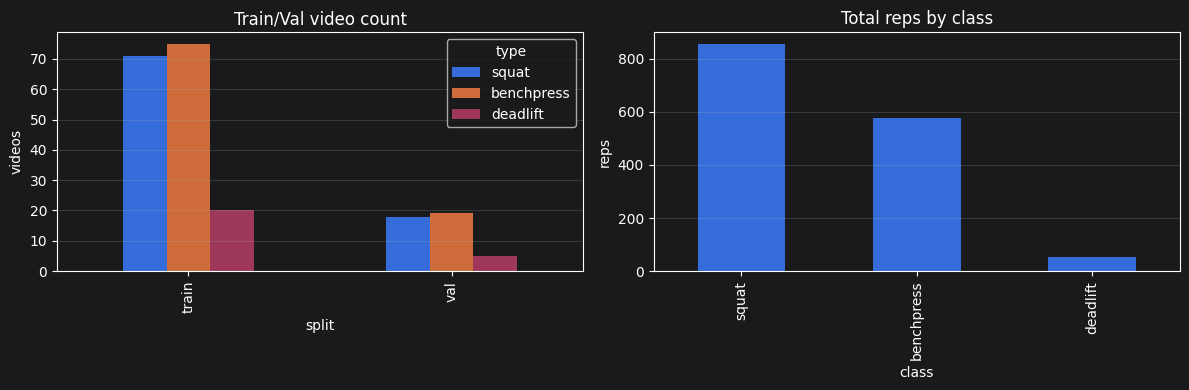

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

split_counts = meta_df.groupby(['split', 'type']).size().unstack(fill_value=0).reindex(['train', 'val'])
split_counts[CLASS_LIST].plot(kind='bar', ax=axes[0])
axes[0].set_title('Train/Val video count')
axes[0].set_xlabel('split')
axes[0].set_ylabel('videos')
axes[0].grid(axis='y', alpha=0.3)

rep_counts = meta_df.groupby('type')['n_reps'].sum().reindex(CLASS_LIST)
rep_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Total reps by class')
axes[1].set_xlabel('class')
axes[1].set_ylabel('reps')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '01_split_distribution.png', dpi=140, bbox_inches='tight')
plt.show()

## 8. 정규화 + Phase target 생성

In [10]:
L_HIP, R_HIP = 23, 24
L_SHO, R_SHO = 11, 12


def normalize_kpts(k):
    """동일한 hip-center / torso-scale 정규화."""
    xy = k[..., :2].copy()
    conf = k[..., 2:3].copy()

    hip = (xy[:, L_HIP] + xy[:, R_HIP]) / 2
    sho = (xy[:, L_SHO] + xy[:, R_SHO]) / 2
    scale = np.linalg.norm(sho - hip, axis=1, keepdims=True) + 1e-6

    xy = (xy - hip[:, None, :]) / scale[:, None, :]
    return np.concatenate([xy, conf], axis=-1).astype(np.float32)


def make_phase_target(T, reps, dtype=np.int64):
    """ready=0, down=1(start~bottom-1), up=2(bottom~finish-1)."""
    phases = np.zeros(T, dtype=dtype)
    for s, b, f in reps:
        s = max(0, min(int(s), T - 1))
        b = max(0, min(int(b), T - 1))
        f = max(0, min(int(f), T - 1))
        if b > s:
            phases[s:b] = PHASE_DOWN
        if f > b:
            phases[b:f] = PHASE_UP
    return phases

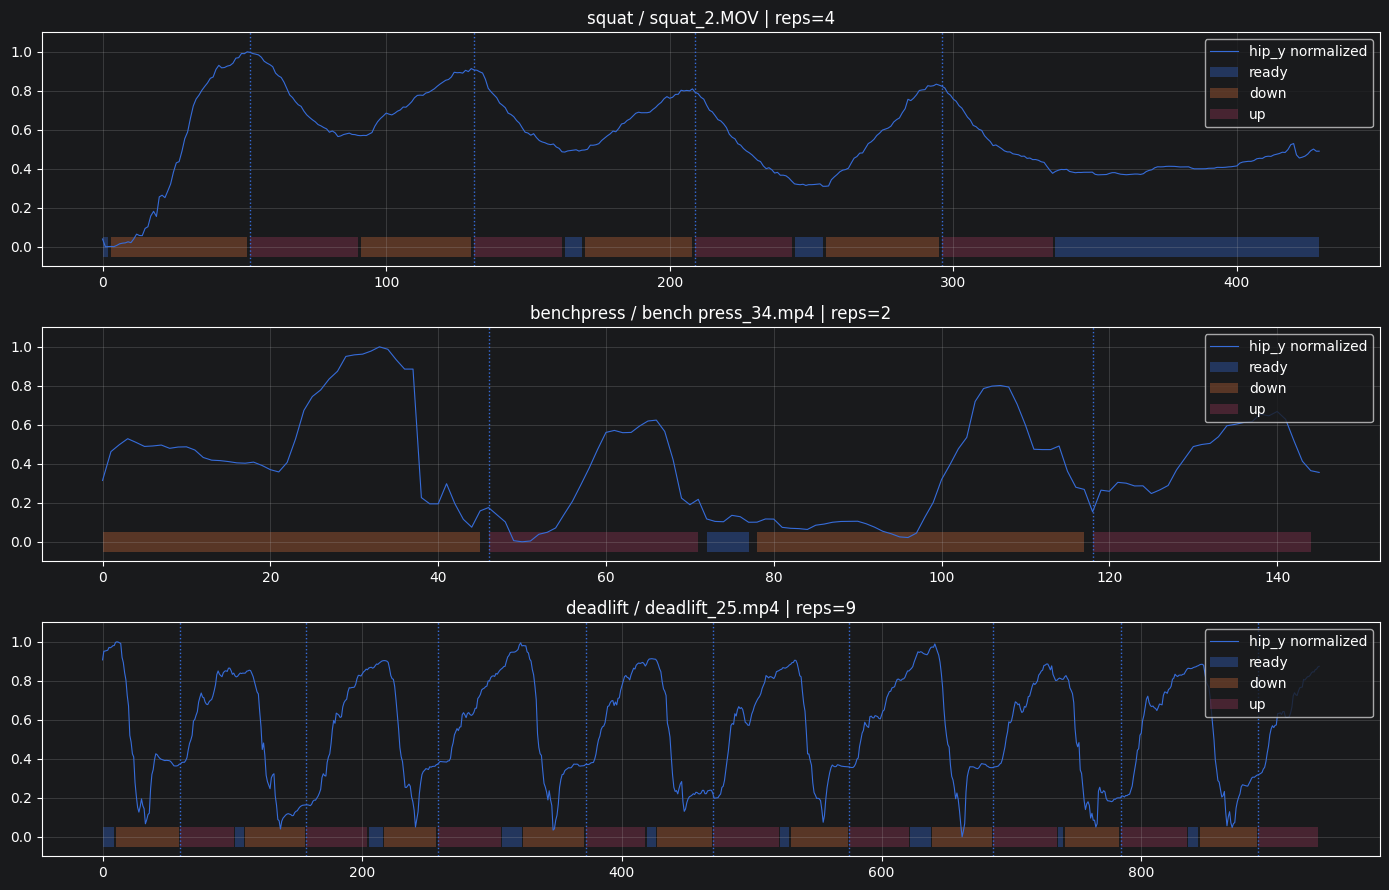

In [11]:
# phase sanity visualization
sample_rows = []
for typ in CLASS_LIST:
    sub = meta_df[(meta_df['type'] == typ) & (meta_df['split'] == 'train') & (meta_df['n_reps'] >= 2)]
    if len(sub):
        sample_rows.append(sub.iloc[0])

if sample_rows:
    fig, axes = plt.subplots(len(sample_rows), 1, figsize=(14, 3 * len(sample_rows)), sharex=False)
    if len(sample_rows) == 1:
        axes = [axes]

    for ax, row in zip(axes, sample_rows):
        k = np.load(row['npz'])['kpts'].astype(np.float32)
        T = min(int(row['T']), len(k))
        phases = make_phase_target(T, LABELS[(row['type'], row['name'])]['reps'])
        hip_y = (k[:T, L_HIP, 1] + k[:T, R_HIP, 1]) / 2
        if hip_y.max() > hip_y.min():
            hip_y = (hip_y - hip_y.min()) / (hip_y.max() - hip_y.min())
        ax.plot(np.arange(T), hip_y, linewidth=0.8, label='hip_y normalized')
        for p, nm in enumerate(PHASE_NAMES):
            mask = phases == p
            ax.fill_between(np.arange(T), -0.05, 0.05, where=mask, alpha=0.35, label=nm)
        for s, b, f in LABELS[(row['type'], row['name'])]['reps']:
            ax.axvline(b, linestyle=':', linewidth=1)
        ax.set_title(f"{row['type']} / {row['name']} | reps={row['n_reps']}")
        ax.set_ylim(-0.1, 1.1)
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(PLOT_DIR / '02_phase_sanity.png', dpi=140, bbox_inches='tight')
    plt.show()

## 9. Augmentation

LSTM이 시간 흐름을 학습해야 하므로 temporal speed/resampling/synthetic stitching은 사용하지 않습니다. 공간 augmentation만 유지합니다.

In [12]:
MP_FLIP_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16),
    (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def aug_horizontal_flip(k):
    k = k.copy()
    k[..., 0] = -k[..., 0]
    for a, b in MP_FLIP_PAIRS:
        tmp = k[:, a].copy()
        k[:, a] = k[:, b]
        k[:, b] = tmp
    return k


def aug_jitter(k, sigma=0.02):
    k = k.copy()
    k[..., :2] += np.random.randn(*k[..., :2].shape).astype(np.float32) * sigma
    return k


def aug_rotation(k, max_deg=15):
    rad = np.deg2rad(np.random.uniform(-max_deg, max_deg))
    cos, sin = np.cos(rad), np.sin(rad)
    R = np.array([[cos, -sin], [sin, cos]], dtype=np.float32)
    k = k.copy()
    k[..., :2] = k[..., :2] @ R.T
    return k


def aug_scale(k, lo=0.9, hi=1.1):
    s = np.random.uniform(lo, hi)
    k = k.copy()
    k[..., :2] *= s
    return k


def apply_spatial_aug(clip, p=0.5):
    if np.random.rand() < p:
        clip = aug_horizontal_flip(clip)
    if np.random.rand() < p:
        clip = aug_rotation(clip, 15)
    if np.random.rand() < p:
        clip = aug_scale(clip)
    if np.random.rand() < p:
        clip = aug_jitter(clip, 0.02)
    return clip

## 10. Causal Sliding Window Dataset

학습 sample 하나는 다음과 같습니다.

```text
X = frame t-95 ~ t
y_phase = phase[t]
```

즉, window 전체 phase sequence가 아니라 **마지막 frame phase만 반환**합니다.

In [13]:
class CausalWindowDataset(Dataset):
    def __init__(self, meta, clip_len=96, stride=2, train=True, aug=True):
        self.meta = meta.reset_index(drop=True).copy()
        self.L = int(clip_len)
        self.stride = int(stride)
        self.train = bool(train)
        self.aug = bool(aug and train)
        self.samples = []

        for row_idx, r in self.meta.iterrows():
            T = int(r['T'])
            reps = LABELS[(r['type'], r['name'])]['reps']
            phases = make_phase_target(T, reps)
            if T <= 0:
                continue

            if T < self.L:
                end_indices = [T - 1]
            else:
                end_indices = list(range(self.L - 1, T, self.stride))
                # 마지막 프레임 평가/학습 포함
                if end_indices[-1] != T - 1:
                    end_indices.append(T - 1)

            for end in end_indices:
                self.samples.append({
                    'row_idx': row_idx,
                    'end': int(end),
                    'phase': int(phases[end]),
                    'cls': int(r['cls']),
                    'type': r['type'],
                    'name': r['name'],
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        r = self.meta.iloc[s['row_idx']]
        k = np.load(r['npz'])['kpts'].astype(np.float32)
        T = min(int(r['T']), len(k))
        k = k[:T]
        k = normalize_kpts(k)

        end = min(s['end'], T - 1)
        start = end - self.L + 1

        if start >= 0:
            clip = k[start:end + 1]
        else:
            # causal padding: 부족한 과거 프레임은 첫 프레임으로 앞쪽 padding
            pad = -start
            clip = np.concatenate([np.tile(k[0:1], (pad, 1, 1)), k[:end + 1]], axis=0)

        assert clip.shape[0] == self.L, clip.shape

        if self.aug:
            clip = apply_spatial_aug(clip, p=0.5)

        x = torch.from_numpy(clip).permute(2, 0, 1).unsqueeze(-1).contiguous()
        y_cls = torch.tensor(s['cls'], dtype=torch.long)
        y_phase = torch.tensor(s['phase'], dtype=torch.long)
        return x, y_cls, y_phase

In [14]:
train_meta = meta_df[meta_df['split'] == 'train'].reset_index(drop=True)
val_meta   = meta_df[meta_df['split'] == 'val'].reset_index(drop=True)

train_ds_probe = CausalWindowDataset(train_meta, CLIP_LEN, TRAIN_STRIDE, train=True, aug=True)
val_ds_probe   = CausalWindowDataset(val_meta, CLIP_LEN, VAL_STRIDE, train=False, aug=False)

print('train videos:', len(train_meta), '| train windows:', len(train_ds_probe))
print('val videos  :', len(val_meta),   '| val windows  :', len(val_ds_probe))

x0, yc0, yp0 = train_ds_probe[0]
print('sample x:', tuple(x0.shape), '| y_cls:', yc0.item(), '| y_phase:', yp0.item(), PHASE_NAMES[yp0.item()])

train videos: 166 | train windows: 54994
val videos  : 42 | val windows  : 22674
sample x: (3, 32, 33, 1) | y_cls: 0 | y_phase: 1 down


## 11. ST-GCN Backbone

기존 backbone을 그대로 사용합니다.

In [15]:
MP_EDGES = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,23),(12,24),(23,24),
    (11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (23,25),(25,27),(27,29),(27,31),(29,31),
    (24,26),(26,28),(28,30),(28,32),(30,32),
]


def build_adjacency(num_node=33, edges=MP_EDGES):
    A = np.zeros((num_node, num_node), dtype=np.float32)
    for i, j in edges:
        A[i, j] = 1.0
        A[j, i] = 1.0
    A += np.eye(num_node, dtype=np.float32)
    D = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-6))
    return D_inv_sqrt @ A @ D_inv_sqrt

A_NORM = torch.from_numpy(build_adjacency()).float()


class GraphConv(nn.Module):
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer('A', A)
        self.conv = nn.Conv2d(in_c, out_c, 1)

    def forward(self, x):
        x = self.conv(x)
        return torch.einsum('nctv,vw->nctw', x, self.A)


class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, kernel_t=9, stride=1, residual=True):
        super().__init__()
        pad = (kernel_t - 1) // 2
        self.gcn = GraphConv(in_c, out_c, A)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, (kernel_t, 1), stride=(stride, 1), padding=(pad, 0)),
            nn.BatchNorm2d(out_c),
        )
        if not residual:
            self.residual = lambda _: 0
        elif in_c == out_c and stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=(stride, 1)),
                nn.BatchNorm2d(out_c),
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        res = self.residual(x)
        x = self.gcn(x)
        x = self.tcn(x)
        return self.relu(x + res)


class STGCNBackbone(nn.Module):
    def __init__(self, in_channels=3, A=A_NORM, base=64):
        super().__init__()
        self.data_bn = nn.BatchNorm1d(in_channels * A.size(0))
        layers = [
            STGCNBlock(in_channels, base,    A, residual=False),
            STGCNBlock(base,        base,    A),
            STGCNBlock(base,        base,    A),
            STGCNBlock(base,        base*2,  A, stride=2),
            STGCNBlock(base*2,      base*2,  A),
            STGCNBlock(base*2,      base*4,  A, stride=2),
            STGCNBlock(base*4,      base*4,  A),
        ]
        self.layers = nn.ModuleList(layers)
        self.out_channels = base * 4

    def forward(self, x):
        # x: [N, C, T, V, M]
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N * M, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)
        for blk in self.layers:
            x = blk(x)
        c, t, v = x.size(1), x.size(2), x.size(3)
        x = x.view(N, M, c, t, v).mean(dim=1)
        return x  # [N, C_out, T', V]

## 12. ST-GCN + LSTM Model

ST-GCN 출력에서 관절축만 평균내고 시간축을 유지한 뒤 LSTM에 넣습니다.

In [16]:
class MultiTaskSTGCNLSTM(nn.Module):
    def __init__(self, num_action=3, num_phase=3, in_c=3,
                 lstm_hidden=128, lstm_layers=1, dropout=0.3):
        super().__init__()
        self.backbone = STGCNBackbone(in_channels=in_c)
        c = self.backbone.out_channels

        self.action_head = nn.Sequential(
            nn.Linear(c, c // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(c // 2, num_action),
        )

        self.lstm = nn.LSTM(
            input_size=c,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=False,
        )

        self.phase_head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_phase),
        )

    def forward(self, x):
        # x: [B, C, T, V, 1]
        f = self.backbone(x)              # [B, D, T', V]

        # 종목 분류: 전체 window의 ST-GCN feature 평균
        action_feat = f.mean(dim=(2, 3))  # [B, D]
        action_logit = self.action_head(action_feat)

        # phase 분류: 시간축 유지 → LSTM
        ft = f.mean(dim=-1)               # [B, D, T']
        ft = ft.permute(0, 2, 1)          # [B, T', D]
        lstm_out, _ = self.lstm(ft)       # [B, T', H]
        last_feat = lstm_out[:, -1, :]    # current time feature
        phase_logit = self.phase_head(last_feat)  # [B, num_phase]

        return action_logit, phase_logit


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_probe = MultiTaskSTGCNLSTM(num_action=NUM_CLASSES, num_phase=NUM_PHASES)
print(f'ST-GCN + LSTM params: {count_params(model_probe):,}')
with torch.no_grad():
    xb = x0.unsqueeze(0)
    a_logit, p_logit = model_probe(xb)
print('action_logit:', tuple(a_logit.shape), '| phase_logit:', tuple(p_logit.shape))

ST-GCN + LSTM params: 2,012,300
action_logit: (1, 3) | phase_logit: (1, 3)


## 13. Loss / smoothing / counting

In [17]:
def multitask_loss(action_logit, phase_logit, y_cls, y_phase,
                   alpha=1.0, class_weight=None, phase_weight=None):
    ce_a = F.cross_entropy(action_logit, y_cls, weight=class_weight)
    ce_p = F.cross_entropy(phase_logit, y_phase, weight=phase_weight)
    return ce_a + alpha * ce_p, ce_a, ce_p


def smooth_phase(phase_seq, window=5):
    phase_seq = np.asarray(phase_seq, dtype=np.int64)
    if window <= 1 or len(phase_seq) == 0:
        return phase_seq
    h = window // 2
    smoothed = np.zeros_like(phase_seq)
    for i in range(len(phase_seq)):
        w = phase_seq[max(0, i-h):min(len(phase_seq), i+h+1)]
        vals, counts = np.unique(w, return_counts=True)
        smoothed[i] = vals[counts.argmax()]
    return smoothed


def count_phases(phase_seq, min_up_len=3):
    """up phase가 끝나는 시점에 +1."""
    count = 0
    transitions = []
    in_up = False
    up_start = -1

    for t, p in enumerate(phase_seq):
        if p == PHASE_UP:
            if not in_up:
                in_up = True
                up_start = t
        else:
            if in_up:
                up_len = t - up_start
                if up_len >= min_up_len:
                    count += 1
                    transitions.append(t)
                in_up = False

    return count, transitions

## 14. 학습 설정 / class weight

In [18]:
EPOCHS = 60
BATCH = 16
LR = 1e-3
WEIGHT_DECAY = 1e-4
PHASE_LOSS_ALPHA = 1.0
LSTM_HIDDEN = 128
LSTM_LAYERS = 1
DROPOUT = 0.3
NUM_WORKERS = 2

CKPT_PATH = CKPT_DIR / 'stgcn_lstm_causal_best.pt'
HISTORY_PATH = WORK_DIR / 'history_stgcn_lstm.json'
RETRAIN = not CKPT_PATH.exists()

train_ds = CausalWindowDataset(train_meta, CLIP_LEN, TRAIN_STRIDE, train=True, aug=True)
val_ds   = CausalWindowDataset(val_meta, CLIP_LEN, VAL_STRIDE, train=False, aug=False)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                    num_workers=NUM_WORKERS, drop_last=False, pin_memory=True)

print(f'train windows={len(train_ds)} | val windows={len(val_ds)} | RETRAIN={RETRAIN}')
print(f'CKPT_PATH={CKPT_PATH}')

train windows=54994 | val windows=22674 | RETRAIN=True
CKPT_PATH=..\data\측면\data\STGCN_LSTM\checkpoints\stgcn_lstm_causal_best.pt


In [19]:
# Epoch checkpoint settings. Stride/window 설정값은 변경하지 않습니다.
EPOCH_CKPT_DIR = CKPT_DIR / 'epoch_checkpoints'
EPOCH_CKPT_DIR.mkdir(parents=True, exist_ok=True)

LATEST_CKPT_PATH = CKPT_DIR / 'stgcn_lstm_causal_latest.pt'
SAVE_EVERY_EPOCH = True
RESUME_LATEST = True

print('BEST CKPT  :', CKPT_PATH)
print('LATEST CKPT:', LATEST_CKPT_PATH)
print('EPOCH DIR  :', EPOCH_CKPT_DIR)


BEST CKPT  : ..\data\측면\data\STGCN_LSTM\checkpoints\stgcn_lstm_causal_best.pt
LATEST CKPT: ..\data\측면\data\STGCN_LSTM\checkpoints\stgcn_lstm_causal_latest.pt
EPOCH DIR  : ..\data\측면\data\STGCN_LSTM\checkpoints\epoch_checkpoints


class sample counts: [28482 24351  2161] weights: [0.644 0.753 8.483]
phase sample counts: [21652 17326 16016] weights: [0.833 1.041 1.126]


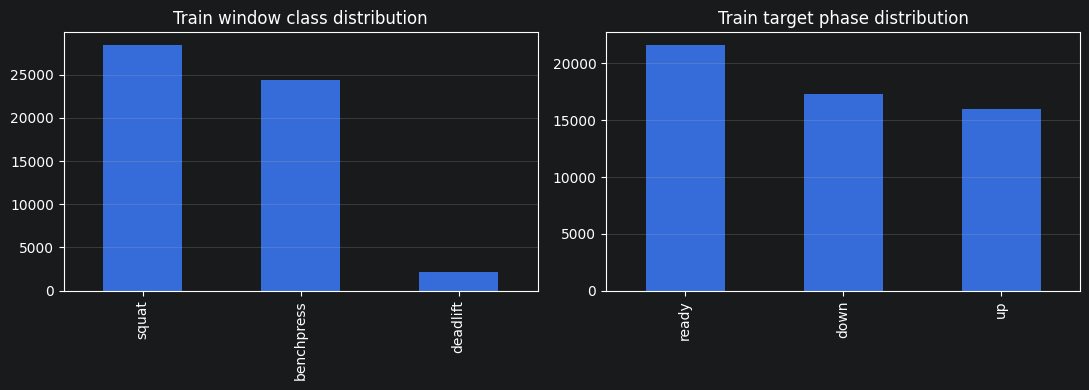

In [20]:
def make_weights_from_dataset(ds):
    cls_counts = np.zeros(NUM_CLASSES, dtype=np.float64)
    phase_counts = np.zeros(NUM_PHASES, dtype=np.float64)
    for s in ds.samples:
        cls_counts[int(s['cls'])] += 1
        phase_counts[int(s['phase'])] += 1

    cls_w = cls_counts.sum() / (NUM_CLASSES * np.maximum(cls_counts, 1))
    phase_freq = phase_counts / max(phase_counts.sum(), 1)
    phase_w = 1.0 / (phase_freq + 1e-6)
    phase_w = phase_w / phase_w.mean()

    return cls_counts, phase_counts, cls_w, phase_w

cls_counts, phase_counts, cls_w, phase_w = make_weights_from_dataset(train_ds)
cls_weight = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)
phase_weight = torch.tensor(phase_w, dtype=torch.float32, device=DEVICE)

print('class sample counts:', cls_counts.astype(int), 'weights:', cls_w.round(3))
print('phase sample counts:', phase_counts.astype(int), 'weights:', phase_w.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(cls_counts, index=CLASS_LIST).plot(kind='bar', ax=axes[0])
axes[0].set_title('Train window class distribution')
axes[0].grid(axis='y', alpha=0.3)
pd.Series(phase_counts, index=PHASE_NAMES).plot(kind='bar', ax=axes[1])
axes[1].set_title('Train target phase distribution')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '03_train_window_distribution.png', dpi=140, bbox_inches='tight')
plt.show()

## 15. Window-level 평가 함수

In [21]:
@torch.no_grad()
def evaluate_windows(model, dl):
    model.eval()
    a_preds, a_gts = [], []
    p_preds, p_gts = [], []
    losses = []

    for x, y_cls, y_phase in dl:
        x = x.to(DEVICE, non_blocking=True)
        y_cls = y_cls.to(DEVICE, non_blocking=True)
        y_phase = y_phase.to(DEVICE, non_blocking=True)

        a_logit, p_logit = model(x)
        loss, _, _ = multitask_loss(
            a_logit, p_logit, y_cls, y_phase,
            alpha=PHASE_LOSS_ALPHA,
            class_weight=cls_weight,
            phase_weight=phase_weight,
        )
        losses.append(float(loss.item()))

        a_preds.extend(a_logit.argmax(1).cpu().tolist())
        a_gts.extend(y_cls.cpu().tolist())
        p_preds.extend(p_logit.argmax(1).cpu().tolist())
        p_gts.extend(y_phase.cpu().tolist())

    return {
        'loss': float(np.mean(losses)) if losses else np.nan,
        'action_acc': accuracy_score(a_gts, a_preds) if a_gts else np.nan,
        'action_f1': f1_score(a_gts, a_preds, average='macro', zero_division=0) if a_gts else np.nan,
        'phase_acc': accuracy_score(p_gts, p_preds) if p_gts else np.nan,
        'phase_f1': f1_score(p_gts, p_preds, average='macro', zero_division=0) if p_gts else np.nan,
        'a_gts': a_gts,
        'a_preds': a_preds,
        'p_gts': p_gts,
        'p_preds': p_preds,
    }

## 16. 학습

In [22]:
def make_checkpoint_payload(epoch, model, optimizer, scheduler, history, best_score, val_metrics=None):
    return {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
        'epoch': int(epoch),
        'best_score': float(best_score),
        'val_metrics': val_metrics,
        'classes': CLASS_LIST,
        'phase_names': PHASE_NAMES,
        'clip_len': CLIP_LEN,
        'train_stride': TRAIN_STRIDE,
        'val_stride': VAL_STRIDE,
        'inference_stride': INFERENCE_STRIDE,
        'model_name': 'STGCN_LSTM_causal_current_phase',
        'config': {
            'lstm_hidden': LSTM_HIDDEN,
            'lstm_layers': LSTM_LAYERS,
            'dropout': DROPOUT,
            'phase_loss_alpha': PHASE_LOSS_ALPHA,
            'lr': LR,
            'weight_decay': WEIGHT_DECAY,
            'seed': SEED,
        },
    }


def save_epoch_checkpoint(epoch, model, optimizer, scheduler, history, best_score, val_metrics=None):
    if not SAVE_EVERY_EPOCH:
        return

    payload = make_checkpoint_payload(
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        history=history,
        best_score=best_score,
        val_metrics=val_metrics,
    )

    # 항상 최신 checkpoint는 덮어쓰기합니다.
    torch.save(payload, LATEST_CKPT_PATH)

    # epoch별 checkpoint도 별도로 저장합니다.
    epoch_path = EPOCH_CKPT_DIR / f'epoch_{epoch:03d}.pt'
    torch.save(payload, epoch_path)

    print(f'[epoch checkpoint saved] {epoch_path}')
    print(f'[latest checkpoint updated] {LATEST_CKPT_PATH}')


def try_resume_latest(model, optimizer, scheduler):
    if not RESUME_LATEST:
        return 1, None, None

    if not LATEST_CKPT_PATH.exists():
        print('[resume] latest checkpoint 없음. 처음부터 학습합니다.')
        return 1, None, None

    ckpt = torch.load(LATEST_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])

    if optimizer is not None and ckpt.get('optimizer') is not None:
        optimizer.load_state_dict(ckpt['optimizer'])

    if scheduler is not None and ckpt.get('scheduler') is not None:
        scheduler.load_state_dict(ckpt['scheduler'])

    last_epoch = int(ckpt.get('epoch', 0))
    start_epoch = last_epoch + 1
    best_score = ckpt.get('best_score', None)
    history = ckpt.get('history', None)

    print(f'[resume] loaded latest checkpoint: {LATEST_CKPT_PATH}')
    print(f'[resume] last_epoch={last_epoch}, start_epoch={start_epoch}, best_score={best_score}')

    return start_epoch, best_score, history


def train_model():
    model = MultiTaskSTGCNLSTM(
        num_action=NUM_CLASSES,
        num_phase=NUM_PHASES,
        in_c=3,
        lstm_hidden=LSTM_HIDDEN,
        lstm_layers=LSTM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    history = {
        'train_loss': [], 'train_ce_a': [], 'train_ce_p': [],
        'val_loss': [], 'val_action_acc': [], 'val_action_f1': [],
        'val_phase_acc': [], 'val_phase_f1': [],
    }
    best_score = -1e9
    start_epoch = 1

    # 중간에 런타임이 끊긴 경우 latest checkpoint에서 이어서 학습합니다.
    resume_epoch, resume_best, resume_history = try_resume_latest(model, opt, sched)
    if resume_epoch is not None:
        start_epoch = resume_epoch
    if resume_best is not None:
        best_score = resume_best
    if resume_history is not None:
        history = resume_history

    if start_epoch > EPOCHS:
        print(f'[resume] start_epoch={start_epoch} > EPOCHS={EPOCHS}. 추가 학습할 epoch이 없습니다.')
        return model, history

    for ep in range(start_epoch, EPOCHS + 1):
        model.train()
        losses, ce_as, ce_ps = [], [], []

        for x, y_cls, y_phase in tqdm(train_dl, desc=f'epoch {ep:02d}', leave=False):
            x = x.to(DEVICE, non_blocking=True)
            y_cls = y_cls.to(DEVICE, non_blocking=True)
            y_phase = y_phase.to(DEVICE, non_blocking=True)

            a_logit, p_logit = model(x)
            loss, ce_a, ce_p = multitask_loss(
                a_logit, p_logit, y_cls, y_phase,
                alpha=PHASE_LOSS_ALPHA,
                class_weight=cls_weight,
                phase_weight=phase_weight,
            )

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()

            losses.append(float(loss.item()))
            ce_as.append(float(ce_a.item()))
            ce_ps.append(float(ce_p.item()))

        sched.step()
        val_metrics = evaluate_windows(model, val_dl)

        history['train_loss'].append(float(np.mean(losses)))
        history['train_ce_a'].append(float(np.mean(ce_as)))
        history['train_ce_p'].append(float(np.mean(ce_ps)))
        history['val_loss'].append(float(val_metrics['loss']))
        history['val_action_acc'].append(float(val_metrics['action_acc']))
        history['val_action_f1'].append(float(val_metrics['action_f1']))
        history['val_phase_acc'].append(float(val_metrics['phase_acc']))
        history['val_phase_f1'].append(float(val_metrics['phase_f1']))

        score = val_metrics['action_f1'] + val_metrics['phase_f1']
        print(
            f"[ep {ep:02d}] "
            f"loss={np.mean(losses):.3f} "
            f"aCE={np.mean(ce_as):.3f} pCE={np.mean(ce_ps):.3f} | "
            f"val a_acc={val_metrics['action_acc']:.3f} a_f1={val_metrics['action_f1']:.3f} "
            f"p_acc={val_metrics['phase_acc']:.3f} p_f1={val_metrics['phase_f1']:.3f}"
        )

        if score > best_score:
            best_score = score
            torch.save({
                'model': model.state_dict(),
                'classes': CLASS_LIST,
                'phase_names': PHASE_NAMES,
                'clip_len': CLIP_LEN,
                'train_stride': TRAIN_STRIDE,
                'val_stride': VAL_STRIDE,
                'inference_stride': INFERENCE_STRIDE,
                'model_name': 'STGCN_LSTM_causal_current_phase',
                'config': {
                    'lstm_hidden': LSTM_HIDDEN,
                    'lstm_layers': LSTM_LAYERS,
                    'dropout': DROPOUT,
                    'phase_loss_alpha': PHASE_LOSS_ALPHA,
                    'lr': LR,
                    'weight_decay': WEIGHT_DECAY,
                    'seed': SEED,
                },
                'epoch': ep,
                'best_score': float(best_score),
            }, CKPT_PATH)
            print(f'[best checkpoint saved] {CKPT_PATH} | best_score={best_score:.4f}')

        with open(HISTORY_PATH, 'w', encoding='utf-8') as f:
            json.dump(history, f, indent=2, ensure_ascii=False)

        # 에폭이 끝날 때마다 latest + epoch별 checkpoint를 저장합니다.
        save_epoch_checkpoint(
            epoch=ep,
            model=model,
            optimizer=opt,
            scheduler=sched,
            history=history,
            best_score=best_score,
            val_metrics=val_metrics,
        )

    print('best score:', best_score)
    print('best saved:', CKPT_PATH)
    print('latest saved:', LATEST_CKPT_PATH)
    return model, history


# if RETRAIN:
#     model, history = train_model()
# else:
#     print('기존 checkpoint 사용:', CKPT_PATH)
#     model = MultiTaskSTGCNLSTM(
#         num_action=NUM_CLASSES,
#         num_phase=NUM_PHASES,
#         in_c=3,
#         lstm_hidden=LSTM_HIDDEN,
#         lstm_layers=LSTM_LAYERS,
#         dropout=DROPOUT,
#     ).to(DEVICE)
#     ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
#     model.load_state_dict(ckpt['model'])
#     model.eval()
#     if HISTORY_PATH.exists():
#         with open(HISTORY_PATH, encoding='utf-8') as f:
#             history = json.load(f)
#     else:
#         history = None


## 17. 학습 곡선 시각화

In [23]:
if history is not None:
    ep = np.arange(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(ep, history['train_loss'], marker='o', label='train')
    axes[0].plot(ep, history['val_loss'], marker='s', label='val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('epoch')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(ep, history['val_action_acc'], marker='o', label='acc')
    axes[1].plot(ep, history['val_action_f1'], marker='s', label='macro-F1')
    axes[1].set_title('Validation action')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    axes[2].plot(ep, history['val_phase_acc'], marker='o', label='acc')
    axes[2].plot(ep, history['val_phase_f1'], marker='s', label='macro-F1')
    axes[2].set_title('Validation phase')
    axes[2].set_xlabel('epoch')
    axes[2].set_ylim(0, 1.05)
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / '04_training_curves.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('history 없음')

NameError: name 'history' is not defined

## 18. Causal inference 함수

프레임이 하나씩 들어온다고 가정하고, 내부적으로 최근 96프레임 window를 만들어 마지막 frame phase만 예측합니다.

In [24]:
@torch.no_grad()
def predict_from_kpts(model, kpts, clip_len=CLIP_LEN, stride=INFERENCE_STRIDE,
                      smooth_window=5, min_up_len=3, batch_size=64):
    model.eval()

    k = normalize_kpts(kpts.astype(np.float32))
    T = len(k)
    if T == 0:
        raise ValueError('empty pose sequence')

    phase_raw = np.zeros(T, dtype=np.int64) + PHASE_READY
    phase_prob = np.zeros((T, NUM_PHASES), dtype=np.float32)
    valid_mask = np.zeros(T, dtype=bool)
    action_probs_all = []

    if T < clip_len:
        ends = [T - 1]
    else:
        ends = list(range(clip_len - 1, T, stride))
        if ends[-1] != T - 1:
            ends.append(T - 1)

    clips = []
    clip_ends = []
    for end in ends:
        start = end - clip_len + 1
        if start >= 0:
            clip = k[start:end + 1]
        else:
            pad = -start
            clip = np.concatenate([np.tile(k[0:1], (pad, 1, 1)), k[:end + 1]], axis=0)
        clips.append(clip)
        clip_ends.append(end)

        if len(clips) == batch_size:
            xb = torch.stack([
                torch.from_numpy(c).permute(2, 0, 1).unsqueeze(-1).contiguous()
                for c in clips
            ]).to(DEVICE)
            a_logit, p_logit = model(xb)
            a_prob = F.softmax(a_logit, dim=1).cpu().numpy()
            p_prob = F.softmax(p_logit, dim=1).cpu().numpy()
            p_pred = p_prob.argmax(axis=1)
            for e, ap, pp, pr in zip(clip_ends, a_prob, p_prob, p_pred):
                action_probs_all.append(ap)
                phase_raw[e] = int(pr)
                phase_prob[e] = pp
                valid_mask[e] = True
            clips, clip_ends = [], []

    if clips:
        xb = torch.stack([
            torch.from_numpy(c).permute(2, 0, 1).unsqueeze(-1).contiguous()
            for c in clips
        ]).to(DEVICE)
        a_logit, p_logit = model(xb)
        a_prob = F.softmax(a_logit, dim=1).cpu().numpy()
        p_prob = F.softmax(p_logit, dim=1).cpu().numpy()
        p_pred = p_prob.argmax(axis=1)
        for e, ap, pp, pr in zip(clip_ends, a_prob, p_prob, p_pred):
            action_probs_all.append(ap)
            phase_raw[e] = int(pr)
            phase_prob[e] = pp
            valid_mask[e] = True

    # stride > 1일 경우 예측 사이 구간을 직전 예측으로 채움. stride=1이면 영향 없음.
    last_phase = PHASE_READY
    last_prob = np.eye(NUM_PHASES, dtype=np.float32)[PHASE_READY]
    for t in range(T):
        if valid_mask[t]:
            last_phase = phase_raw[t]
            last_prob = phase_prob[t]
        else:
            phase_raw[t] = last_phase
            phase_prob[t] = last_prob

    phase_smooth = smooth_phase(phase_raw, window=smooth_window)
    pred_count, transitions = count_phases(phase_smooth, min_up_len=min_up_len)

    if action_probs_all:
        action_vote = np.mean(np.stack(action_probs_all), axis=0)
    else:
        action_vote = np.zeros(NUM_CLASSES, dtype=np.float32)
        action_vote[0] = 1.0
    pred_cls = int(action_vote.argmax())

    return {
        'T': T,
        'pred_cls_id': pred_cls,
        'pred_class': ID_TO_CLASS[pred_cls],
        'action_probs': action_vote,
        'phase_raw': phase_raw,
        'phase_smooth': phase_smooth,
        'phase_prob': phase_prob,
        'valid_mask': valid_mask,
        'pred_count': int(pred_count),
        'transitions': transitions,
    }


@torch.no_grad()
def predict_video_file(model, video_path, clip_len=CLIP_LEN, stride=INFERENCE_STRIDE,
                       smooth_window=5, min_up_len=3):
    video_path = Path(video_path)
    tmp_npz = TMP_DIR / f'tmp_infer_{video_path.stem}.npz'
    T, fps = extract_pose(video_path, tmp_npz)
    kpts = np.load(tmp_npz)['kpts'].astype(np.float32)
    out = predict_from_kpts(model, kpts, clip_len, stride, smooth_window, min_up_len)
    out['fps'] = fps
    out['video_path'] = str(video_path)
    return out

## 19. 단일 영상 테스트 + 시각화

`TEST_VIDEO_PATH = None`이면 validation 영상 중 하나를 자동으로 선택합니다.

In [25]:
TEST_VIDEO_PATH = None  # 예: '/content/drive/MyDrive/data/squat/squat_1.mp4'
SMOOTH_WINDOW = 5
MIN_UP_LEN = 3

if TEST_VIDEO_PATH is None:
    cand = val_meta[val_meta['n_reps'] >= 2]
    if len(cand) == 0:
        cand = val_meta
    sample_row = cand.iloc[0]
    TEST_VIDEO_PATH = sample_row['video_path']
else:
    sample_row = None

print('테스트 영상:', TEST_VIDEO_PATH)

if sample_row is not None:
    kpts = np.load(sample_row['npz'])['kpts'].astype(np.float32)
    out = predict_from_kpts(model, kpts, CLIP_LEN, INFERENCE_STRIDE, SMOOTH_WINDOW, MIN_UP_LEN)
    out['fps'] = float(sample_row['fps'])
    gt_key = (sample_row['type'], sample_row['name'])
else:
    out = predict_video_file(model, TEST_VIDEO_PATH, CLIP_LEN, INFERENCE_STRIDE, SMOOTH_WINDOW, MIN_UP_LEN)
    gt_key = (Path(TEST_VIDEO_PATH).parent.name, Path(TEST_VIDEO_PATH).name)

print('pred class:', out['pred_class'])
print('pred count:', out['pred_count'])
if gt_key in LABELS:
    print('gt class:', gt_key[0])
    print('gt count:', len(LABELS[gt_key]['reps']))
    print('count error:', abs(out['pred_count'] - len(LABELS[gt_key]['reps'])))
print('T:', out['T'], '| fps:', out.get('fps', np.nan))
print('action probs:', {CLASS_LIST[i]: float(out['action_probs'][i]) for i in range(NUM_CLASSES)})

테스트 영상: ..\data\측면\data\squat\squat_3.MOV


NameError: name 'model' is not defined

In [26]:
def plot_single_video_result(out, gt_key=None, title_prefix='single_video'):
    T = out['T']
    t_axis = np.arange(T)

    fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

    axes[0].plot(t_axis, out['phase_raw'], linewidth=0.8, label='raw phase')
    axes[0].plot(t_axis, out['phase_smooth'], linewidth=1.2, label='smoothed phase')
    for tr in out['transitions']:
        axes[0].axvline(tr, linestyle='--', linewidth=1)
    axes[0].set_yticks(range(NUM_PHASES))
    axes[0].set_yticklabels(PHASE_NAMES)
    axes[0].set_title(f"Pred phase | {out['pred_class']} | count={out['pred_count']}")
    axes[0].grid(alpha=0.3)
    axes[0].legend(loc='upper right')

    for p in range(NUM_PHASES):
        axes[1].plot(t_axis, out['phase_prob'][:, p], linewidth=0.9, label=PHASE_NAMES[p])
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_title('Phase probability')
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc='upper right')

    if gt_key in LABELS:
        gt_phase = make_phase_target(T, LABELS[gt_key]['reps'])
        axes[2].plot(t_axis, gt_phase, linewidth=1.0, label='GT phase')
        for s, b, f in LABELS[gt_key]['reps']:
            axes[2].axvline(s, linestyle=':', linewidth=0.8)
            axes[2].axvline(b, linestyle=':', linewidth=0.8)
            axes[2].axvline(f, linestyle=':', linewidth=0.8)
        axes[2].set_yticks(range(NUM_PHASES))
        axes[2].set_yticklabels(PHASE_NAMES)
        axes[2].set_title(f'GT phase | gt_count={len(LABELS[gt_key]["reps"])}')
        axes[2].legend(loc='upper right')
    else:
        axes[2].text(0.5, 0.5, 'GT label not found', ha='center', va='center', transform=axes[2].transAxes)
    axes[2].grid(alpha=0.3)
    axes[2].set_xlabel('frame')

    plt.tight_layout()
    save_path = PLOT_DIR / f'{title_prefix}_phase_timeline.png'
    plt.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()
    print('saved:', save_path)

# plot_single_video_result(out, gt_key=gt_key, title_prefix='05_single_video')

## 20. Validation 전체 평가

종목인식은 `accuracy`, `macro-F1`, 횟수카운팅은 `MAE`, `OBO`를 출력합니다.

In [27]:
def evaluate_val_videos(model, val_meta, smooth_window=5, min_up_len=3):
    rows = []
    all_phase_gt, all_phase_pred = [], []

    for _, r in tqdm(val_meta.iterrows(), total=len(val_meta), desc='val video eval'):
        kpts = np.load(r['npz'])['kpts'].astype(np.float32)
        T = min(int(r['T']), len(kpts))
        kpts = kpts[:T]
        t0 = time.time()
        out = predict_from_kpts(
            model, kpts,
            clip_len=CLIP_LEN,
            stride=INFERENCE_STRIDE,
            smooth_window=smooth_window,
            min_up_len=min_up_len,
        )
        elapsed = time.time() - t0

        gt_key = (r['type'], r['name'])
        gt_count = len(LABELS[gt_key]['reps'])
        gt_phase = make_phase_target(T, LABELS[gt_key]['reps'])

        # warmup 구간은 phase 평가에서 제외. count는 전체 예측 sequence 기준.
        valid_start = CLIP_LEN - 1 if T >= CLIP_LEN else T - 1
        valid_idx = np.arange(T) >= valid_start
        all_phase_gt.extend(gt_phase[valid_idx].tolist())
        all_phase_pred.extend(out['phase_smooth'][valid_idx].tolist())

        rows.append({
            'type': r['type'],
            'name': r['name'],
            'gt_cls': r['type'],
            'pred_cls': out['pred_class'],
            'gt_count': int(gt_count),
            'pred_count': int(out['pred_count']),
            'abs_error': int(abs(out['pred_count'] - gt_count)),
            'signed_error': int(out['pred_count'] - gt_count),
            'T': int(T),
            'fps': float(r['fps']),
            'elapsed_sec': float(elapsed),
            'video_sec': float(T / max(float(r['fps']), 1e-6)),
        })

    vr = pd.DataFrame(rows)

    metrics = {}
    metrics['action_accuracy'] = accuracy_score(vr['gt_cls'], vr['pred_cls']) if len(vr) else np.nan
    metrics['action_macro_f1'] = f1_score(vr['gt_cls'], vr['pred_cls'], average='macro', zero_division=0) if len(vr) else np.nan
    metrics['count_mae'] = mean_absolute_error(vr['gt_count'], vr['pred_count']) if len(vr) else np.nan
    metrics['count_obo'] = (vr['abs_error'] <= 1).mean() if len(vr) else np.nan
    metrics['phase_accuracy'] = accuracy_score(all_phase_gt, all_phase_pred) if all_phase_gt else np.nan
    metrics['phase_macro_f1'] = f1_score(all_phase_gt, all_phase_pred, average='macro', zero_division=0) if all_phase_gt else np.nan
    metrics['rt_factor_mean'] = (vr['elapsed_sec'] / vr['video_sec']).mean() if len(vr) else np.nan

    return vr, metrics, np.asarray(all_phase_gt), np.asarray(all_phase_pred)


# val_results, val_metrics, phase_gt_all, phase_pred_all = evaluate_val_videos(
#     model, val_meta,
#     smooth_window=SMOOTH_WINDOW,
#     min_up_len=MIN_UP_LEN,
# )
#
# VAL_RESULTS_CSV = CSV_DIR / 'val_video_results.csv'
# VAL_METRICS_JSON = WORK_DIR / 'val_metrics.json'
# val_results.to_csv(VAL_RESULTS_CSV, index=False, encoding='utf-8-sig')
# with open(VAL_METRICS_JSON, 'w', encoding='utf-8') as f:
#     json.dump({k: float(v) for k, v in val_metrics.items()}, f, indent=2, ensure_ascii=False)
#
# print('=== Validation metrics ===')
# for k, v in val_metrics.items():
#     print(f'{k:20s}: {v:.4f}')
# print('saved:', VAL_RESULTS_CSV)
# print('saved:', VAL_METRICS_JSON)
#
# print('=== Class report ===')
# print(classification_report(val_results['gt_cls'], val_results['pred_cls'], zero_division=0))
#
# print('=== Count per class ===')
# per_class = val_results.groupby('type').agg(
#     n=('name', 'count'),
#     mae=('abs_error', 'mean'),
#     obo=('abs_error', lambda s: (s <= 1).mean()),
#     mean_gt=('gt_count', 'mean'),
#     mean_pred=('pred_count', 'mean'),
# ).round(3)
# print(per_class)
# per_class.to_csv(CSV_DIR / 'val_count_per_class.csv', encoding='utf-8-sig')

## 21. Validation 결과 시각화

NameError: name 'val_results' is not defined

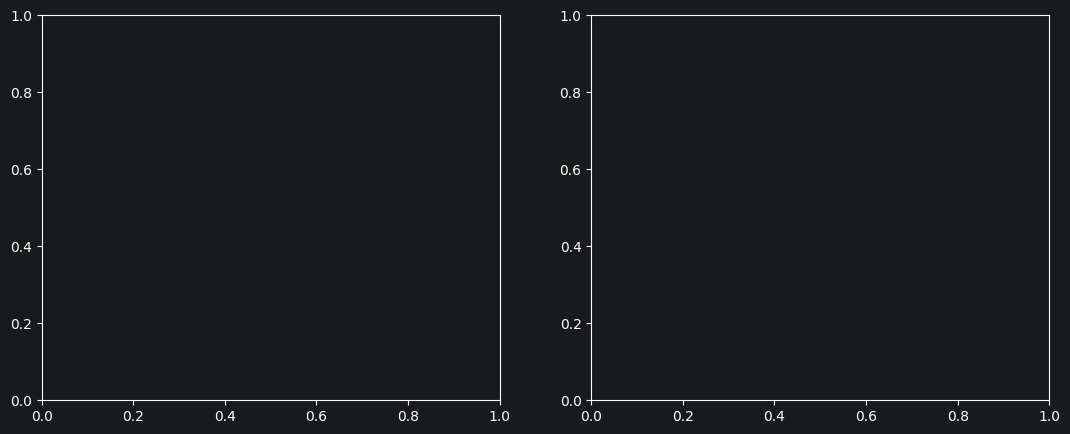

In [28]:
# Action confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_action = confusion_matrix(val_results['gt_cls'], val_results['pred_cls'], labels=CLASS_LIST)
im0 = axes[0].imshow(cm_action)
axes[0].set_title('Action confusion matrix')
axes[0].set_xticks(range(NUM_CLASSES)); axes[0].set_xticklabels(CLASS_LIST, rotation=30)
axes[0].set_yticks(range(NUM_CLASSES)); axes[0].set_yticklabels(CLASS_LIST)
axes[0].set_xlabel('pred'); axes[0].set_ylabel('gt')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[0].text(j, i, str(cm_action[i, j]), ha='center', va='center')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

cm_phase = confusion_matrix(phase_gt_all, phase_pred_all, labels=list(range(NUM_PHASES)))
im1 = axes[1].imshow(cm_phase)
axes[1].set_title('Phase confusion matrix')
axes[1].set_xticks(range(NUM_PHASES)); axes[1].set_xticklabels(PHASE_NAMES, rotation=30)
axes[1].set_yticks(range(NUM_PHASES)); axes[1].set_yticklabels(PHASE_NAMES)
axes[1].set_xlabel('pred'); axes[1].set_ylabel('gt')
for i in range(NUM_PHASES):
    for j in range(NUM_PHASES):
        axes[1].text(j, i, str(cm_phase[i, j]), ha='center', va='center')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(PLOT_DIR / '06_confusion_matrices.png', dpi=140, bbox_inches='tight')
plt.show()

NameError: name 'val_results' is not defined

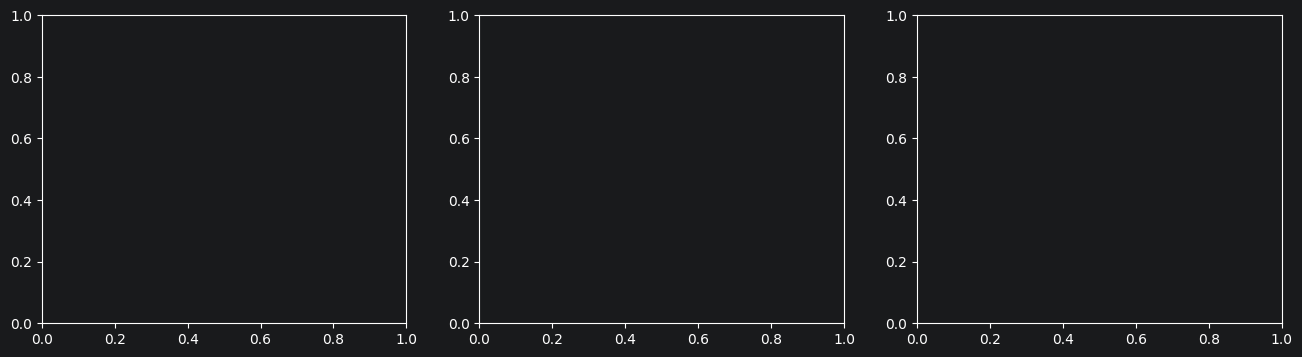

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(val_results['gt_count'], val_results['pred_count'], alpha=0.8)
mx = int(max(val_results['gt_count'].max(), val_results['pred_count'].max())) if len(val_results) else 1
axes[0].plot([0, mx], [0, mx], linestyle='--')
axes[0].set_title('Count: GT vs Pred')
axes[0].set_xlabel('GT count')
axes[0].set_ylabel('Pred count')
axes[0].grid(alpha=0.3)

val_results['abs_error'].hist(bins=range(int(val_results['abs_error'].max()) + 3), ax=axes[1])
axes[1].set_title('Absolute count error')
axes[1].set_xlabel('|pred - gt|')
axes[1].set_ylabel('videos')
axes[1].grid(alpha=0.3)

per_class_plot = val_results.groupby('type')['abs_error'].mean().reindex(CLASS_LIST)
per_class_plot.plot(kind='bar', ax=axes[2])
axes[2].set_title('Count MAE by class')
axes[2].set_xlabel('class')
axes[2].set_ylabel('MAE')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '07_count_results.png', dpi=140, bbox_inches='tight')
plt.show()

In [30]:
# 에러가 큰 영상 확인
cols = ['type', 'name', 'gt_count', 'pred_count', 'abs_error', 'gt_cls', 'pred_cls']
display(val_results.sort_values('abs_error', ascending=False)[cols].head(20))

NameError: name 'val_results' is not defined

## 22. 임의 영상 1개 경로로 테스트하는 함수

아래 함수에 영상 경로 하나를 넣으면 종목/횟수 예측과 phase timeline을 바로 확인할 수 있습니다.

In [31]:
def test_one_video(video_path, smooth_window=5, min_up_len=3, save_prefix='custom_video'):
    video_path = Path(video_path)
    assert video_path.exists(), f'영상 없음: {video_path}'

    out = predict_video_file(
        model, video_path,
        clip_len=CLIP_LEN,
        stride=INFERENCE_STRIDE,
        smooth_window=smooth_window,
        min_up_len=min_up_len,
    )

    gt_key = (video_path.parent.name, video_path.name)
    print('video:', video_path)
    print('pred class:', out['pred_class'])
    print('pred count:', out['pred_count'])
    print('action probs:', {CLASS_LIST[i]: float(out['action_probs'][i]) for i in range(NUM_CLASSES)})

    if gt_key in LABELS:
        print('gt class:', gt_key[0])
        print('gt count:', len(LABELS[gt_key]['reps']))
        print('abs error:', abs(out['pred_count'] - len(LABELS[gt_key]['reps'])))
    else:
        print('GT label not found')

    plot_single_video_result(out, gt_key=gt_key, title_prefix=save_prefix)
    return out

# 사용 예시:
# custom_out = test_one_video('/content/drive/MyDrive/data/squat/example.mp4')

## 23. 산출물 위치

In [ ]:
print('WORK_DIR :', WORK_DIR)
print('best checkpoint  :', CKPT_PATH)
print('latest checkpoint:', LATEST_CKPT_PATH if 'LATEST_CKPT_PATH' in globals() else None)
print('epoch ckpt dir   :', EPOCH_CKPT_DIR if 'EPOCH_CKPT_DIR' in globals() else None)
print('history   :', HISTORY_PATH)
print('metrics   :', VAL_METRICS_JSON)
print('val csv   :', VAL_RESULTS_CSV)
print('plots:')
for p in sorted(PLOT_DIR.glob('*.png')):
    print(' -', p)

# 끝

이 노트북의 핵심 차이:

```text
기존 방식 후보:
96프레임 clip → clip 전체 phase sequence 예측

이 노트북:
과거 96프레임 causal window → 마지막 frame phase 예측
ST-GCN temporal feature sequence → LSTM → current phase
```

비교 실험에서는 기존 모델과 이 모델이 같은 split, 같은 영상/라벨 경로, 같은 정규화, 같은 공간 augmentation을 쓰도록 맞춰두었습니다.

In [32]:
ABLATION_GRID = {
    'model_type'  : ['mlp', 'lstm'],
    'hidden'      : [128],        # lstm_hidden or mlp_hidden
    'lstm_layers' : [1],           # mlp일 땐 무시됨
    'clip_len'    : [16,32, 96],
    'train_stride': [ 2,4],
    'dropout'     : [0.3],
    'aug'         : [True, False],
}

In [ ]:
# ============================================================
# Ablation Experiment Cell (LSTM vs MLP)
# ※ 위 셀들이 모두 실행된 상태에서 실행하세요
# ============================================================

import itertools, json, time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

# ── MLP 모델 정의 (LSTM 대신 MLP로 phase 예측) ───────────────
class MultiTaskSTGCNMLP(nn.Module):
    def __init__(self, num_action=3, num_phase=3, in_c=3,
                 mlp_hidden=128, dropout=0.3):
        super().__init__()
        self.backbone = STGCNBackbone(in_channels=in_c)
        c = self.backbone.out_channels  # 256

        self.action_head = nn.Sequential(
            nn.Linear(c, c // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(c // 2, num_action),
        )

        self.phase_head = nn.Sequential(
            nn.Linear(c, mlp_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden // 2, num_phase),
        )

    def forward(self, x):
        f = self.backbone(x)              # [B, D, T', V]
        feat = f.mean(dim=(2, 3))         # [B, D] 시간+관절 평균
        action_logit = self.action_head(feat)
        phase_logit  = self.phase_head(feat)
        return action_logit, phase_logit


# ── 모델 생성 팩토리 ──────────────────────────────────────────
def build_model(cfg):
    if cfg['model_type'] == 'lstm':
        return MultiTaskSTGCNLSTM(
            num_action=NUM_CLASSES, num_phase=NUM_PHASES, in_c=3,
            lstm_hidden=cfg['hidden'], lstm_layers=cfg['lstm_layers'],
            dropout=cfg['dropout'],
        ).to(DEVICE)
    else:  # mlp
        return MultiTaskSTGCNMLP(
            num_action=NUM_CLASSES, num_phase=NUM_PHASES, in_c=3,
            mlp_hidden=cfg['hidden'],
            dropout=cfg['dropout'],
        ).to(DEVICE)


# ── 실험 그리드 ───────────────────────────────────────────────
ABLATION_GRID = {
    'model_type'  : ['mlp', 'lstm'],
    'hidden'      : [128],        # lstm_hidden or mlp_hidden
    'lstm_layers' : [1],           # mlp일 땐 무시됨
    'clip_len'    : [16,32, 96],
    'train_stride': [ 2,4],
    'dropout'     : [0.3],
    'aug'         : [True, False],
}

# 직접 지정하려면 여기에, None이면 그리드 전체
ABLATION_CONFIGS = None

# ── 고정 설정 ─────────────────────────────────────────────────
FIXED = dict(
    epochs           = EPOCHS,
    batch            = BATCH,
    lr               = LR,
    weight_decay     = WEIGHT_DECAY,
    phase_loss_alpha = PHASE_LOSS_ALPHA,
    smooth_window    = 5,
    min_up_len       = 3,
    num_workers      = NUM_WORKERS,
)

# ── 저장 경로 ─────────────────────────────────────────────────
ABLATION_ROOT     = WORK_DIR / 'ablation'
ABLATION_ROOT.mkdir(parents=True, exist_ok=True)
ABLATION_LOG_CSV  = ABLATION_ROOT / 'ablation_results.csv'
ABLATION_LOG_JSON = ABLATION_ROOT / 'ablation_results.json'


# ── 실험 이름 ─────────────────────────────────────────────────
def make_exp_name(cfg):
    base = (
        f"{cfg['model_type']}"
        f"_h{cfg['hidden']}"
        f"_c{cfg['clip_len']}"
        f"_ts{cfg['train_stride']}"
        f"_do{str(cfg['dropout']).replace('.','')}"
        f"_aug{int(cfg['aug'])}"
    )
    if cfg['model_type'] == 'lstm':
        base += f"_l{cfg['lstm_layers']}"
    return base


# ── 가중치 계산 ───────────────────────────────────────────────
def compute_weights_from_ds(ds):
    cls_c   = np.zeros(NUM_CLASSES, dtype=np.float64)
    phase_c = np.zeros(NUM_PHASES,  dtype=np.float64)
    for s in ds.samples:
        cls_c[int(s['cls'])]     += 1
        phase_c[int(s['phase'])] += 1
    cls_w   = cls_c.sum() / (NUM_CLASSES * np.maximum(cls_c, 1))
    phase_w = 1.0 / (phase_c / max(phase_c.sum(), 1) + 1e-6)
    phase_w = phase_w / phase_w.mean()
    return (
        torch.tensor(cls_w,   dtype=torch.float32, device=DEVICE),
        torch.tensor(phase_w, dtype=torch.float32, device=DEVICE),
    )


# ── 윈도우 단위 검증 ──────────────────────────────────────────
@torch.no_grad()
def ablation_eval_windows(model, dl, cw, pw):
    model.eval()
    a_preds, a_gts, p_preds, p_gts, losses = [], [], [], [], []
    for x, y_cls, y_phase in dl:
        x, y_cls, y_phase = x.to(DEVICE), y_cls.to(DEVICE), y_phase.to(DEVICE)
        a_logit, p_logit  = model(x)
        loss, _, _ = multitask_loss(
            a_logit, p_logit, y_cls, y_phase,
            alpha=FIXED['phase_loss_alpha'], class_weight=cw, phase_weight=pw,
        )
        losses.append(float(loss.item()))
        a_preds.extend(a_logit.argmax(1).cpu().tolist())
        a_gts.extend(y_cls.cpu().tolist())
        p_preds.extend(p_logit.argmax(1).cpu().tolist())
        p_gts.extend(y_phase.cpu().tolist())
    return {
        'val_loss'      : float(np.mean(losses)),
        'action_acc'    : accuracy_score(a_gts, a_preds),
        'action_f1'     : f1_score(a_gts, a_preds, average='macro', zero_division=0),
        'phase_acc'     : accuracy_score(p_gts, p_preds),
        'phase_f1'      : f1_score(p_gts, p_preds, average='macro', zero_division=0),
    }


# ── 영상 단위 최종 평가 ───────────────────────────────────────
def ablation_eval_videos(model, val_meta, clip_len, stride):
    rows = []
    all_gt, all_pred = [], []
    for _, r in val_meta.iterrows():
        kpts = np.load(r['npz'])['kpts'].astype(np.float32)
        T    = min(int(r['T']), len(kpts))
        out  = predict_from_kpts(
            model, kpts[:T],
            clip_len=clip_len,
            stride=stride,
            smooth_window=FIXED['smooth_window'],
            min_up_len=FIXED['min_up_len'],
        )
        gt_key   = (r['type'], r['name'])
        gt_count = len(LABELS[gt_key]['reps'])
        gt_phase = make_phase_target(T, LABELS[gt_key]['reps'])
        valid    = np.arange(T) >= (clip_len - 1 if T >= clip_len else T - 1)
        all_gt.extend(gt_phase[valid].tolist())
        all_pred.extend(out['phase_smooth'][valid].tolist())
        rows.append({
            'type'      : r['type'],
            'gt_cls'    : r['type'],
            'pred_cls'  : out['pred_class'],
            'gt_count'  : gt_count,
            'pred_count': out['pred_count'],
            'abs_error' : abs(out['pred_count'] - gt_count),
        })
    vr = pd.DataFrame(rows)

    # 종목별 count MAE / OBO
    per_class = {}
    for typ in CLASS_LIST:
        sub = vr[vr['type'] == typ]
        if len(sub) == 0:
            per_class[f'mae_{typ}'] = float('nan')
            per_class[f'obo_{typ}'] = float('nan')
        else:
            per_class[f'mae_{typ}'] = float(sub['abs_error'].mean())
            per_class[f'obo_{typ}'] = float((sub['abs_error'] <= 1).mean())

    return {
        'video_action_acc': accuracy_score(vr['gt_cls'], vr['pred_cls']),
        'video_action_f1' : f1_score(vr['gt_cls'], vr['pred_cls'], average='macro', zero_division=0),
        'video_phase_acc' : accuracy_score(all_gt, all_pred) if all_gt else float('nan'),
        'video_phase_f1'  : f1_score(all_gt, all_pred, average='macro', zero_division=0) if all_gt else float('nan'),
        'video_count_mae' : mean_absolute_error(vr['gt_count'], vr['pred_count']),
        'video_count_obo' : float((vr['abs_error'] <= 1).mean()),
        **per_class,
    }


# ── 단일 실험 ─────────────────────────────────────────────────
def run_one_experiment(cfg, train_meta, val_meta):
    exp_name    = make_exp_name(cfg)
    exp_dir     = ABLATION_ROOT / exp_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    latest_path = exp_dir / 'latest.pt'
    hist_path   = exp_dir / 'history.json'

    print(f'\n{"="*60}')
    print(f'[EXP] {exp_name}')
    print(f'  model={cfg["model_type"]} hidden={cfg["hidden"]} '
          f'clip={cfg["clip_len"]} stride={cfg["train_stride"]} '
          f'drop={cfg["dropout"]} aug={cfg["aug"]}')

    # 완료 스킵 (best_ep*.pt 또는 latest.pt 탐색)
    existing_bests = sorted(exp_dir.glob('best_ep*.pt'))
    is_done = hist_path.exists() and (existing_bests or latest_path.exists())
    if is_done:
        best_path = existing_bests[-1] if existing_bests else latest_path
        print(f'  → 완료된 실험 ({best_path.name}), 평가만 진행')
        model = build_model(cfg)
        ckpt  = torch.load(best_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        model.eval()
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        vm = ablation_eval_videos(model, val_meta, cfg['clip_len'], cfg['train_stride'])
        return {'exp_name': exp_name, **cfg,
                'num_params'    : num_params,
                'best_epoch'    : ckpt.get('best_epoch', -1),
                'best_val_score': ckpt.get('best_score', float('nan')),
                'elapsed_min': 0, 'skipped': True, **vm}

    # Dataset
    train_ds = CausalWindowDataset(
        train_meta, clip_len=cfg['clip_len'], stride=cfg['train_stride'],
        train=True, aug=cfg['aug'],
    )
    val_ds = CausalWindowDataset(
        val_meta, clip_len=cfg['clip_len'], stride=cfg['train_stride'],
        train=False, aug=False,
    )
    train_dl = DataLoader(train_ds, batch_size=FIXED['batch'], shuffle=True,
                          num_workers=FIXED['num_workers'], drop_last=True, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=FIXED['batch'], shuffle=False,
                          num_workers=FIXED['num_workers'], pin_memory=True)
    print(f'  train={len(train_ds)} | val={len(val_ds)} windows')

    cw, pw = compute_weights_from_ds(train_ds)
    model  = build_model(cfg)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  params={num_params:,}')
    opt    = torch.optim.Adam(model.parameters(), lr=FIXED['lr'], weight_decay=FIXED['weight_decay'])
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FIXED['epochs'])

    history     = {'train_loss': [], 'val_action_acc': [], 'val_action_f1': [],
                   'val_phase_acc': [], 'val_phase_f1': []}
    best_score  = -1e9
    best_epoch  = -1
    start_epoch = 1

    # resume
    if latest_path.exists():
        ck = torch.load(latest_path, map_location=DEVICE)
        model.load_state_dict(ck['model'])
        opt.load_state_dict(ck['optimizer'])
        sched.load_state_dict(ck['scheduler'])
        start_epoch = int(ck.get('epoch', 0)) + 1
        best_score  = ck.get('best_score', -1e9)
        best_epoch  = ck.get('best_epoch', -1)
        history     = ck.get('history', history)
        print(f'  → resume from epoch {start_epoch}')

    t0 = time.time()

    # best_path 초기화 (resume 시 루프가 안 돌 수도 있으므로)
    existing_bests = sorted(exp_dir.glob('best_ep*.pt'))
    if existing_bests:
        best_path = existing_bests[-1]
    elif latest_path.exists():
        best_path = latest_path          # best 없으면 latest로 fallback
    else:
        best_path = exp_dir / 'best_ep000.pt'

    for ep in range(start_epoch, FIXED['epochs'] + 1):
        model.train()
        losses = []
        for x, y_cls, y_phase in train_dl:
            x, y_cls, y_phase = x.to(DEVICE), y_cls.to(DEVICE), y_phase.to(DEVICE)
            a_logit, p_logit  = model(x)
            loss, _, _ = multitask_loss(
                a_logit, p_logit, y_cls, y_phase,
                alpha=FIXED['phase_loss_alpha'], class_weight=cw, phase_weight=pw,
            )
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            losses.append(float(loss.item()))
        sched.step()

        vm    = ablation_eval_windows(model, val_dl, cw, pw)
        score = vm['action_f1'] + vm['phase_f1']

        history['train_loss'].append(float(np.mean(losses)))
        history['val_action_acc'].append(vm['action_acc'])
        history['val_action_f1'].append(vm['action_f1'])
        history['val_phase_acc'].append(vm['phase_acc'])
        history['val_phase_f1'].append(vm['phase_f1'])

        print(f"  [ep {ep:02d}/{FIXED['epochs']}] "
              f"loss={np.mean(losses):.3f} | "
              f"a_acc={vm['action_acc']:.3f} a_f1={vm['action_f1']:.3f} "
              f"p_acc={vm['phase_acc']:.3f} p_f1={vm['phase_f1']:.3f} score={score:.3f}")

        if score > best_score:
            best_score = score
            best_epoch = ep
            # 이전 best 파일 삭제 후 새 이름으로 저장
            for old in exp_dir.glob('best_ep*.pt'):
                old.unlink()
            best_path = exp_dir / f'best_ep{ep:03d}.pt'
            torch.save({'model': model.state_dict(), 'cfg': cfg,
                        'epoch': ep, 'best_score': float(best_score),
                        'best_epoch': ep,
                        'clip_len': cfg['clip_len'],
                        'classes': CLASS_LIST, 'phase_names': PHASE_NAMES}, best_path)

        torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                    'scheduler': sched.state_dict(), 'history': history,
                    'cfg': cfg, 'epoch': ep, 'best_score': float(best_score),
                    'best_epoch': best_epoch}, latest_path)

        with open(hist_path, 'w') as f:
            json.dump(history, f, indent=2)

    elapsed = time.time() - t0
    print(f'  → 완료 | best_score={best_score:.4f} | {elapsed/60:.1f}min')

    ck = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ck['model'])
    model.eval()
    vm = ablation_eval_videos(model, val_meta, cfg['clip_len'], cfg['train_stride'])
    print(f'  → best: {best_path.name}')

    return {'exp_name': exp_name, **cfg,
            'num_params'     : num_params,
            'best_epoch'     : best_epoch,
            'best_val_score' : float(best_score),
            'elapsed_min'    : round(elapsed / 60, 1),
            'skipped'        : False, **vm}


# ── 실험 목록 생성 ────────────────────────────────────────────
if ABLATION_CONFIGS is None:
    keys = list(ABLATION_GRID.keys())
    ABLATION_CONFIGS = [
        dict(zip(keys, v))
        for v in itertools.product(*ABLATION_GRID.values())
    ]
    # mlp는 lstm_layers 의미 없으므로 중복 제거
    seen, unique = set(), []
    for c in ABLATION_CONFIGS:
        key = make_exp_name(c)
        if key not in seen:
            seen.add(key)
            unique.append(c)
    ABLATION_CONFIGS = unique

print(f'총 실험 수: {len(ABLATION_CONFIGS)}개')
for i, c in enumerate(ABLATION_CONFIGS):
    print(f'  [{i+1:02d}] {make_exp_name(c)}')

# 기존 결과 로드
all_results = []
if ABLATION_LOG_JSON.exists():
    with open(ABLATION_LOG_JSON) as f:
        all_results = json.load(f)
    print(f'\n기존 결과 {len(all_results)}개 로드')

done_names = {r['exp_name'] for r in all_results}

# ── 전체 실험 실행 ────────────────────────────────────────────
for i, cfg in enumerate(ABLATION_CONFIGS):
    exp_name = make_exp_name(cfg)
    if exp_name in done_names and any((ABLATION_ROOT / exp_name).glob('best_ep*.pt')):
        print(f'[{i+1}/{len(ABLATION_CONFIGS)}] {exp_name} → 스킵')
        continue

    result = run_one_experiment(cfg, train_meta, val_meta)
    all_results.append(result)
    done_names.add(exp_name)

    with open(ABLATION_LOG_JSON, 'w') as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
    pd.DataFrame(all_results).to_csv(ABLATION_LOG_CSV, index=False, encoding='utf-8-sig')

# ── 결과 요약 ─────────────────────────────────────────────────
results_df = (pd.DataFrame(all_results)
              .sort_values('video_count_obo', ascending=False)
              .reset_index(drop=True))

print('\n' + '='*70)
print('Ablation 결과 (video_count_obo 기준)')
print('='*70)

show = ['exp_name', 'model_type', 'hidden', 'lstm_layers', 'clip_len',
        'train_stride', 'dropout', 'aug',
        'num_params', 'best_epoch', 'best_val_score',
        'video_action_acc', 'video_action_f1',
        'video_phase_acc', 'video_phase_f1',
        'video_count_mae', 'video_count_obo',
        'mae_squat', 'obo_squat',
        'mae_benchpress', 'obo_benchpress',
        'mae_deadlift', 'obo_deadlift',
        'elapsed_min']
print(results_df[[c for c in show if c in results_df.columns]].to_string())
print(f'\n저장: {ABLATION_LOG_CSV}')

총 실험 수: 24개
  [01] mlp_h128_c16_ts2_do03_aug1
  [02] mlp_h128_c16_ts2_do03_aug0
  [03] mlp_h128_c16_ts4_do03_aug1
  [04] mlp_h128_c16_ts4_do03_aug0
  [05] mlp_h128_c32_ts2_do03_aug1
  [06] mlp_h128_c32_ts2_do03_aug0
  [07] mlp_h128_c32_ts4_do03_aug1
  [08] mlp_h128_c32_ts4_do03_aug0
  [09] mlp_h128_c96_ts2_do03_aug1
  [10] mlp_h128_c96_ts2_do03_aug0
  [11] mlp_h128_c96_ts4_do03_aug1
  [12] mlp_h128_c96_ts4_do03_aug0
  [13] lstm_h128_c16_ts2_do03_aug1_l1
  [14] lstm_h128_c16_ts2_do03_aug0_l1
  [15] lstm_h128_c16_ts4_do03_aug1_l1
  [16] lstm_h128_c16_ts4_do03_aug0_l1
  [17] lstm_h128_c32_ts2_do03_aug1_l1
  [18] lstm_h128_c32_ts2_do03_aug0_l1
  [19] lstm_h128_c32_ts4_do03_aug1_l1
  [20] lstm_h128_c32_ts4_do03_aug0_l1
  [21] lstm_h128_c96_ts2_do03_aug1_l1
  [22] lstm_h128_c96_ts2_do03_aug0_l1
  [23] lstm_h128_c96_ts4_do03_aug1_l1
  [24] lstm_h128_c96_ts4_do03_aug0_l1

기존 결과 4개 로드

[EXP] mlp_h128_c16_ts2_do03_aug1
  model=mlp hidden=128 clip=16 stride=2 drop=0.3 aug=True
  → 완료된 실험 (latest.